This code simulatenously runs FBR simulation, standard TN simulation, and compares this against a dynamical map.

Max difference in alpha: 3.376689861056548e-8, Max difference in beta: 1.6802546909389093e-8 with delta: 5.0e-7
(st.t, st.step) = (0.01, 1)
After sweep 1: maxlinkdim=7 maxerr=0.00E+00 current_time=0.0 - 0.01im time=0.039
maxlinkdim(st.psi) = 7
maximum(pop_active) = 4.4952003547192975e-5
Time for step: 1.2745909690856934 seconds


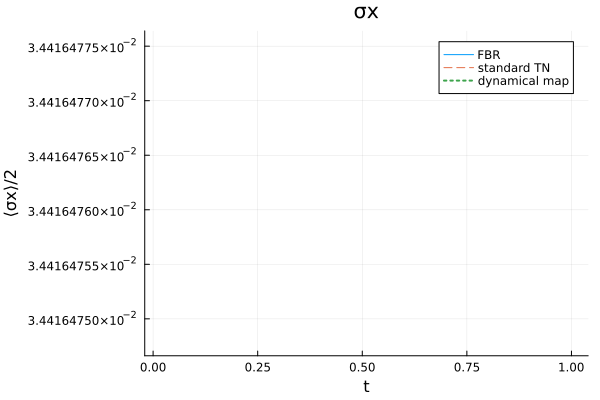

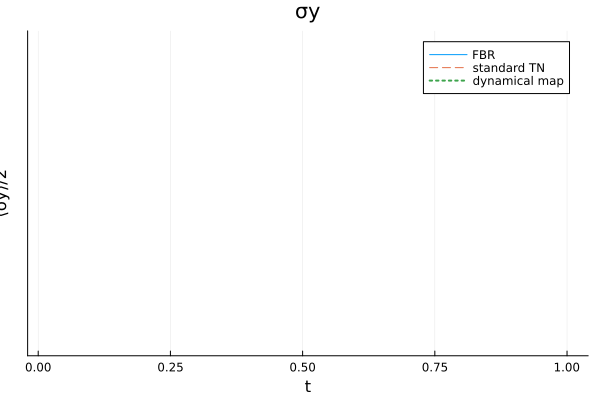

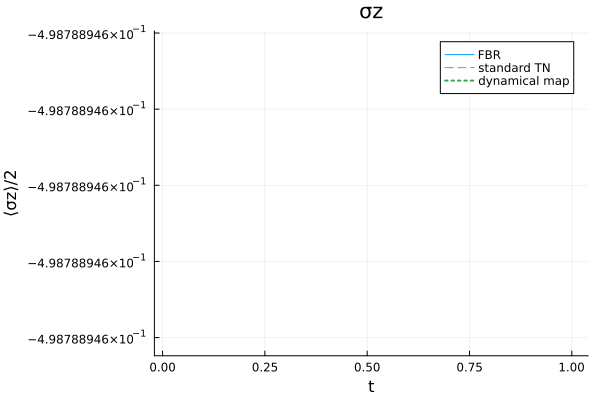

(st.t, st.step) = (0.02, 2)
After sweep 1: maxlinkdim=11 maxerr=0.00E+00 current_time=0.0 - 0.01im time=0.078
maxlinkdim(st.psi) = 11
maximum(pop_active) = 0.0001794716585819983
Time for step: 0.22253203392028809 seconds


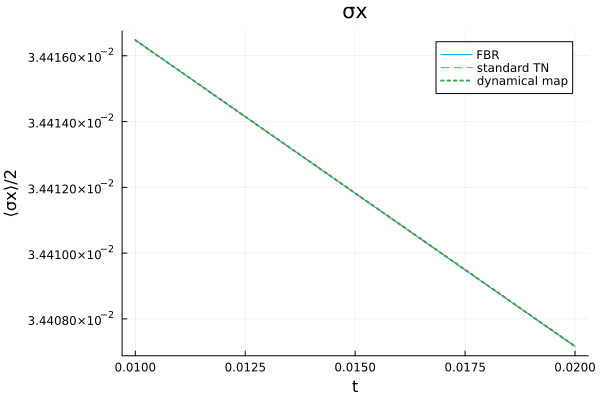

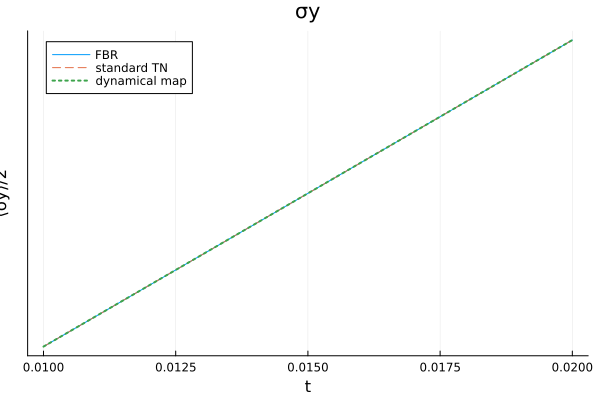

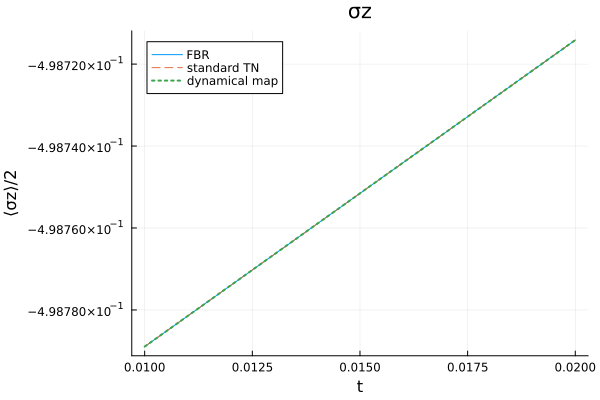

(st.t, st.step) = (0.03, 3)
After sweep 1: maxlinkdim=11 maxerr=0.00E+00 current_time=0.0 - 0.01im time=0.071
maxlinkdim(st.psi) = 11
maximum(pop_active) = 0.0004025614060523168
Time for step: 0.20206999778747559 seconds


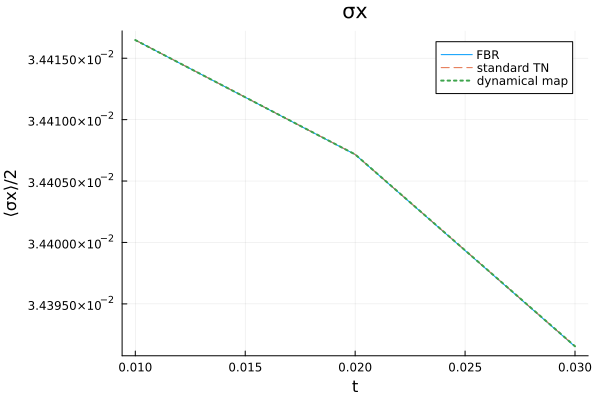

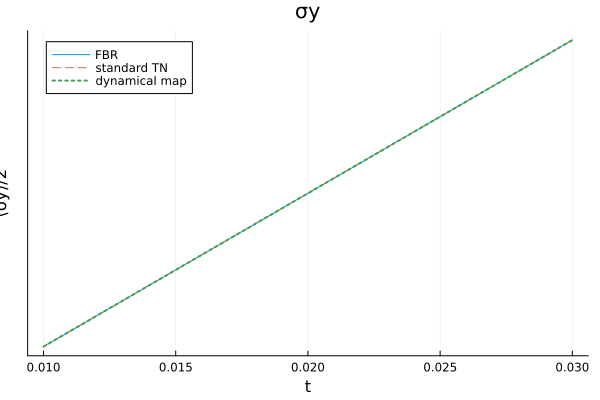

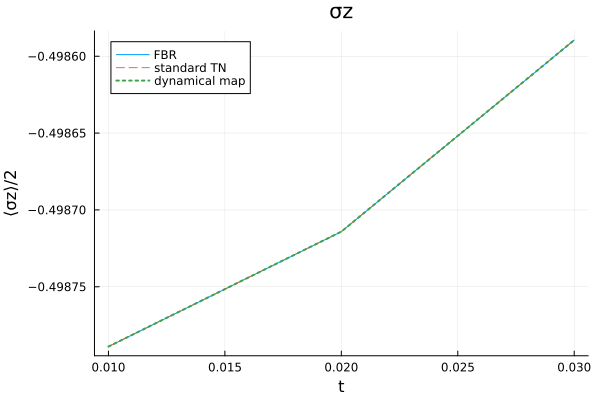

(st.t, st.step) = (0.04, 4)
After sweep 1: maxlinkdim=11 maxerr=0.00E+00 current_time=0.0 - 0.01im time=0.084
maxlinkdim(st.psi) = 11
maximum(pop_active) = 0.0007125961245314515
Time for step: 0.21970009803771973 seconds


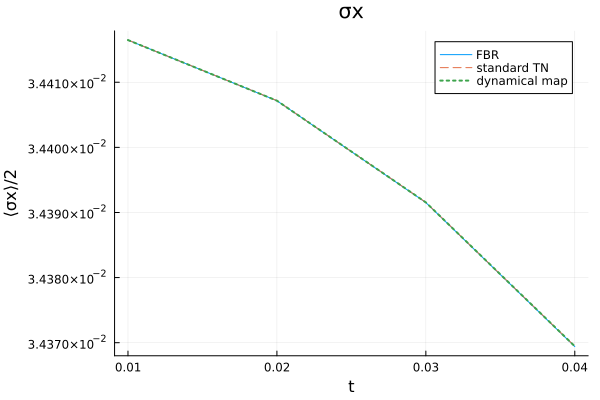

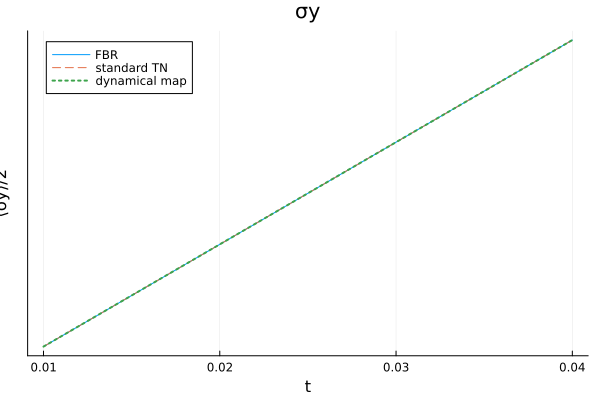

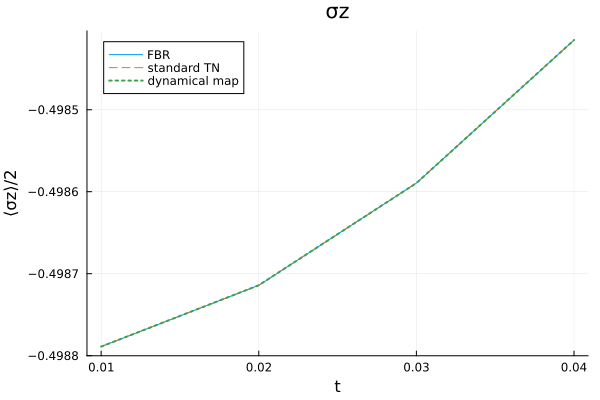

(st.t, st.step) = (0.05, 5)
After sweep 1: maxlinkdim=11 maxerr=0.00E+00 current_time=0.0 - 0.01im time=0.073
maxlinkdim(st.psi) = 11
maximum(pop_active) = 0.001107376353573763
Time for step: 0.20706915855407715 seconds


LoadError: InterruptException:

In [ ]:
using ITensors, ITensorMPS, LinearAlgebra, Plots, JLD2, CSV, DataFrames, PolyChaos
BLAS.set_num_threads(1) # avoid multi-threading issues with BLAS in correlation matrix calculation

# Define a trivial qubit space for QN conservation
function ITensors.space(::SiteType"QubitWithQN";
    conserve_qns::Bool=false, 
    qnname::String="Q")
    conserve_qns ? [QN(qnname, 0) => 2] : 2    
end

# Define states for qubit with QN
function ITensors.state(::StateName{name}, ::SiteType"QubitWithQN", s::Index) where {name}
    nm = string(name)
    if nm == "0"
        return onehot(s => 1)
    elseif nm == "1"
        return onehot(s => 2)
    else
        error("Unknown state name: $name, use 0 or 1.")
    end
end

# Define operators for qubit with QN
ITensors.op(::OpName"Id", ::SiteType"QubitWithQN") = [1 0; 0 1]
ITensors.op(::OpName"Z",  ::SiteType"QubitWithQN") = [1 0; 0 -1]
ITensors.op(::OpName"X",  ::SiteType"QubitWithQN") = [0 1; 1 0]
ITensors.op(::OpName"Y",  ::SiteType"QubitWithQN") = [0 -im; im 0]

# Define "balancing" (shift) operators for conserving QN via ancilla
function ITensors.op(::OpName"Beta", ::SiteType"Boson", d::Int)
    M = zeros(d, d)
    for n in 1:d-1
        M[n+1, n] = 1.0
    end
    return M
end

function ITensors.op(::OpName"BetaDag", ::SiteType"Boson", d::Int)
    M = zeros(d, d)
    for n in 2:d
        M[n-1, n] = 1.0
    end
    return M
end

struct SimParams
    L::Int # Total length of bath chain, not including impurity.
    nImp::Int # Number of impurity sites
    dt::Float64 # Time step
    nsteps::Int # Number of time steps to evolve
    wmax::Float64 # high freq cutoff
    wc::Float64 # exponential cutoff frequency, for using with exp-ohmic
    alpha::Float64 # coupling strength
    epsilon_sigmaz::Float64 # impurity energy splitting
    delta::Float64 # sigma_x term strength
    qubitinitial_0amp::Float64 # a|0> init amplitude, calc b|1> from normalization
    bathtype::String # sharpohmic, expohmic
    finiteT::Bool # whether to run at T=0 or finite T
    beta::Float64 # inverse temperature for finite T runs
    s::Float64 # ohmic bath exponent

    optimalLocalBasisCutoff::Float64 # cutoff for discarding states in optimal local basis, only for TEBD
    probabilityBosonDim::Float64 # threshold for discarding bosonic states based on their probability in the local state
    epsilon::Float64 # tolerance for empty/full
    apply_cutoff::Float64 # cutoff for applying truncation
    time_evolution_cutoff::Float64 # cutoff for time evolution
    plotting::Bool # whether to plot results as sim progresses
    save_results::Bool # whether to save results to file
    output::Bool # whether to print results to console
end

mutable struct SimState
    psi::MPS
    F::Matrix{ComplexF64} # rotating frame
    active::Vector{Int} # active bath sites in rotating frame
    step::Int
    t::Float64
    ni::Vector{Float64} # occupation of each mode, cheaper than handling full cc
    cc_active::Matrix{ComplexF64} # correlation matrix of active subspace
    sites::Vector{Index} # site indices of the MPS, needed for local dimension update
    R::Vector{ITensor} # local optimal basis rotation matrix

    # Measurements:
    times::Vector{Float64} # time points for measurements
    # impurity measurements:
    sigma_z_expectation::Vector{Float64}
    sigma_x_expectation::Vector{Float64}
    sigma_y_expectation::Vector{Float64}
    # computational cost measurements:
    num_active_modes::Vector{Int}
    max_bond_dimension::Vector{Int}
    population_active_modes::Matrix{Float64}
    local_dimensions::Matrix{Int}
    bare_dimensions::Matrix{Int}
    timestep_timings::Vector{Float64}
end

mutable struct Gate
    modes::Vector{Int}
    c::ComplexF64
    s::ComplexF64
end

function boseEinsteinFunction(beta, omega)
    return 1.0/expm1(beta * omega)
end

function heavisideFunction(x)
    return x > 0 ? 1.0 : 0.0
end

function bathSpectralFunction(p::SimParams)
    if p.bathtype == "sharpohmic"
        J = (ω::Float64) -> 2.0 * p.alpha * ω * heaviside(p.wmax - ω)
        supp = (-p.wmax, p.wmax)
    elseif p.bathtype == "expohmic"
        J = (ω::Float64) -> 2.0 * p.alpha * p.wc^(1 - p.s) * ω^p.s * exp(-ω / p.wc)
        supp = (-10.0 * p.wc, 10.0 * p.wc)
    elseif p.bathtype == "customLorentzian" # highly structured spectral function from a paper 
        rescale = 100
        Svec = [0.39, 0.23, 0.23]
        Sigmavec = [0.4, 0.25, 0.2]
        omegavec = [26.0, 51.0, 85.0]./rescale
        Omegavec = [181.0, 221.0, 240.0]./rescale
        gvec = [0.0173, 0.0246, 0.0182]
        gamma = 5.0/rescale
        renorm = 1.0
        function J(ω::Float64)
            if ω <= 0
                return 0.0
            end
            Jval = 0.0
            for k in 1:length(Svec)
                exponent = -(log(ω/omegavec[k])^2)/(2*Sigmavec[k]^2)
                Jk = ω * exp(exponent)
                Jk *= Svec[k]/(Sigmavec[k]*sqrt(2.0+pi))
                Jval += Jk
            end
            for k in 1:length(Omegavec)
                numerator = 4.0 * gamma * Omegavec[k] * gvec[k] * (Omegavec[k]^2 + gamma^2) * ω
                denominator = pi * (gamma^2 + (ω + Omegavec[k])^2)*(gamma^2 + (ω - Omegavec[k])^2)
                Jm = numerator/denominator
                Jval += Jm
            end
            return Jval * renorm * heavisideFunction(350 - ω)
        end
        supp = (-5,5)
    else
        throw(ArgumentError("Invalid bath type: $(p.bathtype)"))
    end
    return J, supp
end

function generateTTEDOPACoefficients(p::SimParams)
    J, supp = bathSpectralFunction(p)
    Jthermal(x) = begin 
        wabs = abs(x)
        Jv = J(wabs)
        nv = boseEinsteinFunction(p.beta, wabs)
        Jv * (nv + heavisideFunction(x))
    end

    if p.L > 100
        @warn "L is too large to calculate all T-TEDOPA coeffs - assumed to be constant after 100 coeffs."
        coeffLength = 100
    else
        coeffLength = p.L
    end


    wmin, wmax = supp[1], supp[2]
    function makequad(a,b,wfun)
        return N -> begin
            xbar, wbar = fejer(N)
            x = ((b-a)/2) .* xbar .+ ((b+a)/2)
            w = (b-a)/2 .* wbar .* wfun.(x)
            return x, w
        end
    end

    w_left(x) = Jthermal(x)
    w_right(x) = Jthermal(x)

    tol=1E-2
    delta=1E-6
    delta_min = 1E-12
    alpha, beta, alpha_old, beta_old = nothing, nothing, nothing, nothing
    


    quad_left = makequad(wmin, -delta, w_left)
    quad_right = makequad(delta, wmax, w_right)
    while true
        quad_left = makequad(wmin, -delta, w_left)
        quad_right = makequad(delta, wmax, w_right)
        quads = [quad_left, quad_right]
        alpha_new, beta_new = mcdiscretization(coeffLength, quads; discretization=lanczos, Nmax=10000000, ε=1E-8)
        if alpha_old !== nothing 
            maxdiff_alpha, maxdiff_beta = maximum(abs.(alpha_new .- alpha_old)), maximum(abs.(sqrt.(beta_new) .- sqrt.(beta_old)))
            println("Max difference in alpha: ", maxdiff_alpha, ", Max difference in beta: ", maxdiff_beta, " with delta: ", delta)
            if maxdiff_alpha <= tol && maxdiff_beta <= tol
                alpha, beta = alpha_new, beta_new
                break
            end
        end
        alpha_old_true, beta_old_true = alpha_old, beta_old
        alpha_old, beta_old = alpha_new, beta_new
        delta = delta/2
        if delta < delta_min
            @warn "Delta reached minimum value without convergence, results may not be fully converged!"
            alpha, beta = alpha_new, beta_new
            break
        end
    end


    if p.L > 100
        alpha_actual = zeros(p.L)
        alpha_actual[1:length(alpha)] .= alpha
        alpha_actual[length(alpha)+1:end] .= alpha[end]

        beta_actual = zeros(p.L)
        beta_actual[1:length(beta)] .= beta
        beta_actual[length(beta)+1:end] .= beta[end]
    else
        alpha_actual = alpha
        beta_actual = beta
    end



    return alpha_actual, sqrt.(beta_actual)
end

function generateDiscretisedBathCoefficients(p::SimParams)
    if p.bathtype == "sharpohmic"
        Omega = collect(range(0.0, p.wmax; length=p.L+1))
        w = zeros(Float64, p.L)
        g = zeros(Float64, p.L)
        for k in 1:p.L
            g[k] = p.alpha *(Omega[k+1]^2 - Omega[k]^2)
            w[k] = (2/3) * p.alpha * (Omega[k+1]^3 - Omega[k]^3)/g[k]
        end
        g = sqrt.(g)
        return w, g
    elseif p.bathtype == "expohmic"
        wmax = 10 * p.wc

        Omega = collect(range(0.0, wmax; length=p.L+1))
        w = zeros(Float64, p.L)
        g = zeros(Float64, p.L)  
        for k in 1:p.L
            g[k] = 2 * p.alpha * p.wc * (-exp(-Omega[k+1]/p.wc)*(p.wc+Omega[k+1]) + exp(-Omega[k]/p.wc)*(p.wc+Omega[k]))
            w[k] = -2 * p.alpha * p.wc * (exp(-Omega[k+1]/p.wc) * (2*p.wc^2 + 2*p.wc*Omega[k+1] + Omega[k+1]^2) - exp(-Omega[k]/p.wc) * (2*p.wc^2 + 2*p.wc*Omega[k] + Omega[k]^2))/g[k]
        end
        g = sqrt.(g)
        return w, g
    else
        error("Unknown bathtype: $(p.bathtype)")
    end
end

function generateHamiltonianCoefficients(p::SimParams)
    # Function returns Hbath matrix and eta vector, contains all coeffs for chain
    if p.finiteT # generate T-TEDOPA coeffs
        E, J = generateTTEDOPACoefficients(p)
        Hb = zeros(ComplexF64, p.L, p.L)
        for i in 1:p.L-1
            Hb[i,i+1] = J[i+1]
            Hb[i+1,i] = J[i+1]
        end
        for i in 1:p.L
            Hb[i,i] = E[i]
        end
        eta = zeros(ComplexF64, p.L)
        eta[1] = J[1]

        return Hb, eta
    else # generate standard coeffs for discretised J
        w, g = generateDiscretisedBathCoefficients(p)
        Hb = diagm(w)
        eta = g
        return Hb, eta
    end
end

function increaseLocalDimensionQN!(st::SimState, p::SimParams, sites, ni_active)
    active_modes = st.active
    sites = siteinds(st.psi)

    anc = p.nImp + 1     
    bath0 = p.nImp + 2      

    # temporarily add a site to active mode
    if isempty(active_modes)
        push!(active_modes, 1)
    else
        next = active_modes[end] + 1
        if next <= p.L
            push!(active_modes, next)
        end
    end

    prob_n(rho::ITensor, s::Index, n::Int) = real((dag(onehot(prime(s) => n)) * rho * onehot(s => n))[])

    # compute the probability of maximum occupation for each active mode
    boson_dimensions = fill(1, p.L)

    
    for i in active_modes
        j = p.nImp + 1 + i             # absolute site index of bath mode i
        boson_dimensions[i] = ITensors.dim(sites[j])
        s = sites[j]
        orthogonalize!(st.psi, j)
        nmax = ITensors.dim(s)

        rhoj = prime(st.psi[j], s) * dag(st.psi[j])
        rhojM = Array(rhoj, prime(s), dag(s))
        probs = real.(diag(rhojM))

        prob = probs[end]
        for x in 1:3
            if length(probs) > x
                prob += probs[end-x] # also consider probability of second highest occupation, to avoid getting stuck at dim=2 if dim=3 is actually needed.
            end
        end


        if prob > p.probabilityBosonDim
            boson_dimensions[i] += 2
        end
    end

    psi = copy(st.psi)
    orthogonalize!(psi, min(2, length(psi)))
    for i in 1:p.L
        oldsite = sites[p.nImp + 1 + i]
        boson_dimensions[i] = max(boson_dimensions[i], ITensors.dim(oldsite)) # ensure increases only
    end
    
    # Ancilla dim must match bath mode 1
    anc_dim = boson_dimensions[1]

    # construct the site inds: [impurities..., ancilla, bath...]
    newsiteinds_bath = [siteind("Boson"; conserve_qns=true, dim=d) for d in boson_dimensions]
    newsiteinds = vcat(
        [siteind("QubitWithQN"; conserve_qns=true) for _ in 1:p.nImp]...,
        siteind("Boson"; conserve_qns=true, dim=anc_dim),
        newsiteinds_bath...
    )

    # embed old MPS into new sites
    N = p.nImp + 1 + p.L
    psiExpanded = Vector{ITensor}(undef, N)

    for j in 1:p.nImp
        psiExpanded[j] = psi[j]
    end

    begin
        A = psi[anc]
        oldsite = sites[anc]
        newsite = newsiteinds[anc]

        if oldsite == newsite
            psiExpanded[anc] = A
        else
            inds_A = collect(inds(A))
            k = findfirst(==(oldsite), inds_A)
            inds_A[k] = newsite

            A_pad = ITensor(inds_A...)
            for n in 1:ITensors.dim(oldsite)
                A_pad += (A * dag(onehot(oldsite => n))) * onehot(newsite => n)
            end
            psiExpanded[anc] = A_pad
        end
    end

    for i in 1:p.L
        j = p.nImp + 1 + i
        A = psi[j]

        oldsite = sites[j]
        newsite = newsiteinds[j]

        if oldsite == newsite
            psiExpanded[j] = A
            continue
        end

        inds_A = collect(inds(A))
        k = findfirst(==(oldsite), inds_A)
        inds_A[k] = newsite

        A_pad = ITensor(inds_A...)
        for n in 1:ITensors.dim(oldsite)
            A_pad += (A * dag(onehot(oldsite => n))) * onehot(newsite => n)
        end

        psiExpanded[j] = A_pad
    end

    st.psi = MPS(psiExpanded)
    orthogonalize!(st.psi, min(2, length(st.psi)))
    return siteinds(st.psi)
end

function initializeSimState(p::SimParams)
    chainLength = p.L + p.nImp + 1
    sites = siteinds("Boson", chainLength; conserve_qns=true, dim=1)
    sites[1] = siteind("QubitWithQN"; conserve_qns=true)
    active_dims = 11 # start with dim=11 for first 10 modes to allow for active growth
    for j in 2:6
        sites[j] = siteind("Boson"; conserve_qns=true, dim=active_dims)
    end
    # and make sure site 2,3 have a large initial dim, for num conservation
    initdim = 40
    sites[2] = siteind("Boson"; conserve_qns=true, dim=initdim)
    sites[3] = siteind("Boson"; conserve_qns=true, dim=initdim)
    states = ["0" for i in 1:chainLength] # initial vac state
    states[p.nImp + 1] = string(initdim - 1) # ancilla maximally occupied.
   

    psi = MPS(sites, states)

    l1 = linkind(psi, 1)
    A1 = ITensor(sites[1], l1)
    A1[sites[1] => 1, l1 => 1] = p.qubitinitial_0amp
    A1[sites[1] => 2, l1 => 1] = sqrt(1.0 - abs2(p.qubitinitial_0amp))
    psi[1] = A1

    F = Matrix{ComplexF64}(I, p.L, p.L) # start in non-rotating frame


    cc = zeros(ComplexF64, p.L, p.L)
    ni = real.(diag(cc))
    active = findall((ni .> p.epsilon))

    R_vec = []
    sites = siteinds(psi)


    st = SimState(psi, F, active, 0, 0.0, zeros(Float64, p.L), zeros(Float64, p.L, p.L), sites, R_vec, Float64[], Float64[], Float64[], Float64[], Int[], Int[], zeros(Float64, p.L, p.nsteps), zeros(Int, chainLength, p.nsteps), zeros(Int, chainLength, p.nsteps), Float64[])
    return st
end

function initializeStandardMPS(p::SimParams; bathdim::Int=40)
    chainLength = p.L + 1

    sites = Vector{Index}(undef, chainLength)
    sites[1] = siteind("Qubit")

    for j in 2:chainLength
        sites[j] = siteind("Boson"; dim=bathdim)
    end

    states = fill("0", chainLength)

    psi = MPS(sites, states)

    l1 = linkind(psi, 1)
    A1 = ITensor(sites[1], l1)
    A1[sites[1] => 1, l1 => 1] = p.qubitinitial_0amp
    A1[sites[1] => 2, l1 => 1] = sqrt(1.0 - abs2(p.qubitinitial_0amp))
    psi[1] = A1

    return psi
end

function standardHamiltonianMPO(p::SimParams, sites, Hb::Matrix{ComplexF64}, eta::Vector{ComplexF64})
    op = OpSum()

    imp = 1
    bathsite(i) = 1 + i

    # system Hamiltonian
    op += 0.5 * p.epsilon_sigmaz, "Z", imp
    op += 0.5 * p.delta, "X", imp

    # bath Hamiltonian: sum_ij Hb[i,j] a_i^† a_j
    for i in 1:p.L
        si = bathsite(i)

        if abs(Hb[i, i]) > 1e-14
            op += real(Hb[i, i]), "N", si
        end

        for j in 1:p.L
            if i != j && abs(Hb[i, j]) > 1e-14
                sj = bathsite(j)
                op += Hb[i, j], "Adag", si, "A", sj
            end
        end
    end

    # system-bath coupling in the unrotated chain/star basis
    for i in 1:p.L
        if abs(eta[i]) > 1e-14
            si = bathsite(i)

            op += eta[i],       "Z", imp, "Adag", si
            op += conj(eta[i]), "Z", imp, "A",    si
        end
    end

    return MPO(op, sites)
end

function measureStandard!(psi_std::MPS, t, times, sx, sy, sz, maxdims)
    push!(times, t)

    push!(sx, expect(psi_std, "X"; sites=1) / 2)
    push!(sy, expect(psi_std, "Y"; sites=1) / 2)
    push!(sz, expect(psi_std, "Z"; sites=1) / 2)

    push!(maxdims, maxlinkdim(psi_std))

    return nothing
end

function givens_rotation(v_in::AbstractVector{ComplexF64}, modes::AbstractVector{<:Integer})
    m = length(modes)
    v = copy(v_in)
    G_subsys = Matrix{ComplexF64}(I, m, m)
    gates = Gate[]
    sizehint!(gates, max(m - 1, 0))

    if m <= 1
        return G_subsys, gates
    end

    for j in (m - 1):-1:1
        a = v[j]
        b = v[j + 1]
        r2 = abs2(a) + abs2(b)

        if r2 > 1e-30
            r  = sqrt(r2)
            aN = a / r
            bN = b / r
            c  = abs(aN)
            s  = (c > 1e-15) ? (aN * conj(bN) / c) : (-conj(bN))
        else
            c = 1.0
            s = 0.0 + 0.0im
        end

        push!(gates, Gate([Int(modes[j]), Int(modes[j + 1])], ComplexF64(c), s))

        vj  = v[j]
        vjp = v[j + 1]
        v[j]     = c * vj + s * vjp
        v[j + 1] = -conj(s) * vj + c * vjp

        for col in 1:m
            x = G_subsys[j, col]
            y = G_subsys[j + 1, col]
            G_subsys[j, col]     = c * x + s * y
            G_subsys[j + 1, col] = -conj(s) * x + c * y
        end
    end

    return G_subsys, gates
end

function apply_givens_left!(x::AbstractVector{ComplexF64}, g::Gate)
    i, j = g.modes
    xi, xj = x[i], x[j]
    x[i] = g.c * xi + g.s * xj
    x[j] = -conj(g.s) * xi + g.c * xj
    return x
end

function apply_givens_left!(x::AbstractVector{ComplexF64}, gates::AbstractVector{Gate})
    for g in gates
        apply_givens_left!(x, g)
    end
    return x
end

function apply_givens_left!(M::AbstractMatrix{ComplexF64}, g::Gate)
    i, j = g.modes
    @views begin
        ri = copy(M[i, :])
        rj = copy(M[j, :])
        M[i, :] .= g.c .* ri .+ g.s .* rj
        M[j, :] .= -conj(g.s) .* ri .+ g.c .* rj
    end
    return M
end

function apply_givens_left!(M::AbstractMatrix{ComplexF64}, gates::AbstractVector{Gate})
    for g in gates
        apply_givens_left!(M, g)
    end
    return M
end

function apply_givens_right_dag!(M::AbstractMatrix{ComplexF64}, g::Gate)
    i, j = g.modes
    @views begin
        ci = copy(M[:, i])
        cj = copy(M[:, j])
        M[:, i] .= g.c .* ci .+ conj(g.s) .* cj
        M[:, j] .= -g.s .* ci .+ g.c .* cj
    end
    return M
end

function apply_givens_right_dag!(M::AbstractMatrix{ComplexF64}, gates::AbstractVector{Gate})
    for g in gates
        apply_givens_right_dag!(M, g)
    end
    return M
end

function apply_givens_similarity!(C::AbstractMatrix{ComplexF64}, g::Gate)
    apply_givens_left!(C, g)
    apply_givens_right_dag!(C, g)
    return C
end

function apply_givens_similarity!(C::AbstractMatrix{ComplexF64}, gates::AbstractVector{Gate})
    for g in gates
        apply_givens_similarity!(C, g)
    end
    return C
end

function remap_gates(gates_local::AbstractVector{Gate}, labels::AbstractVector{<:Integer})
    gates = Gate[]
    sizehint!(gates, length(gates_local))
    for g in gates_local
        push!(gates, Gate([Int(labels[g.modes[1]]), Int(labels[g.modes[2]])], g.c, g.s))
    end
    return gates
end

function localiseHc2Rot!(st::SimState, p::SimParams, eta_tc_rot::Vector{ComplexF64}, ni_bath::Vector{Float64})

    gates_emp = Gate[]
    nActive = length(st.active)

    if nActive >= p.L
        println("All modes active, skipping localisation.")
        return gates_emp, eta_tc_rot
    end

    tail = (nActive + 1):p.L
    empty = findall(x -> x < 0.5, view(ni_bath, tail)) .+ nActive
    couplings = eta_tc_rot[empty]

    if !isempty(empty) && norm(couplings) > p.epsilon
        _, gates_emp = givens_rotation(couplings, empty)

        # exact replacement for eta_tc_rot = G_emp * eta_tc_rot
        apply_givens_left!(eta_tc_rot, gates_emp)

        push!(st.active, empty[1])
        sort!(st.active)

    end

    return gates_emp, eta_tc_rot
end

function applyGivens!(st::SimState, p::SimParams, givens_gates, sites, L)
    for g in givens_gates

        s1, s2 = g.modes[1], g.modes[2]

        s1 += p.nImp + 1
        s2 += p.nImp + 1


        if s1 + 1 != s2
            println("s1: ", s1, " s2: ", s2)
            println("MPS Active:", st.active)
            error("Givens rotation can only be applied to adjacent modes.")
        end
            
            s1s, s2s = siteind(st.psi, s1), siteind(st.psi, s2)

            c = clamp(real(g.c), 0, 1.0)
            theta = acos(c)
            phi = (abs(g.s) > 0) ? angle(g.s) : 0.0
            alpha = theta * cis(phi)
            K = alpha * op("Adag", s1s) * op("A", s2s) - conj(alpha) * op("Adag", s2s) * op("A", s1s)
            U = exp(K)
     
            st.psi = apply(U, st.psi; cutoff=p.apply_cutoff, maxdim=1E10) 

            st.sites = siteinds(st.psi) # update sites after potential change in optimal basis

    end
    normalize!(st.psi)
    return nothing
end

function calculateCorrelationMatrix(st::SimState, p::SimParams, sites; init_corr_calc=false)
        cc = Matrix{ComplexF64}(correlation_matrix(st.psi, "Adag", "A"; sites=sites))
    return cc
end

function calculateDensity(st::SimState, p::SimParams)

        d = expect(st.psi, "N"; sites=p.nImp + 2 : p.nImp + 1 + p.L)


    return d
end

function timeEvolve!(st::SimState, p::SimParams, eta_tc_rot, sites)
   
    ni_bath = st.ni
    increaseLocalDimensionQN!(st, p, siteinds(st.psi), ni_bath)
              
    dims = [Int(ITensors.dim(siteind(st.psi, i))) for i in 1:length(siteinds(st.psi))]
    st.bare_dimensions[:, st.step] = dims
    
    op = OpSum()
    op += 0.5*p.epsilon_sigmaz, "Z", 1
    op += 0.5*p.delta, "X", 1
    op += eta_tc_rot[1], "Z", 1, "BetaDag", 2, "Adag", 3
    op += conj(eta_tc_rot[1]), "Z", 1, "Beta", 2, "A", 3

    H = MPO(op, siteinds(st.psi))
    if st.step == 1
        st.psi = expand(st.psi, H; alg="global_krylov", krylovdim=6, cutoff=1E-14, apply_kwargs=(; maxdim=3000, cutoff=1E-20))
    end
    st.psi = expand(st.psi, H; alg="global_krylov", krylovdim=3, cutoff=1E-8, apply_kwargs=(; maxdim=3000, cutoff=1E-20))
    st.psi = tdvp(H, -1im * p.dt, st.psi; cutoff=p.time_evolution_cutoff, nsteps=1, outputlevel=1, nsite=1, normalize=true)

 
    st.sites = siteinds(st.psi) # update sites after potential change in optimal basis
    @show maxlinkdim(st.psi)

    return sites
end

function active_diagonalization(st::SimState, p::SimParams)
    nactive = length(st.active)

    if nactive == 0
        return Matrix{ComplexF64}(I, p.L, p.L), Gate[], ComplexF64[]
    end

    gates_nat = Gate[]
    sizehint!(gates_nat, nactive * (nactive - 1) ÷ 2)

    V = Matrix{ComplexF64}(I, p.L, p.L)

    # Keep exactly the same object as before, but update it in active-space coordinates
    first_active = minimum(st.active) + 2
    last_active = maximum(st.active) + 2
    sites=first_active:last_active
    cc_active = calculateCorrelationMatrix(st, p, sites)
    rho_sub = Matrix(transpose(cc_active)) # need to transpose to match the convention of rho_sub = V_col * rho_sub * V_col' where V_col acts on columns of rho_sub. This is because correlation_matrix returns <A_i A_j^dag> = (V_col * rho_sub * V_col')[i,j] = sum_k V_col[i,k] * rho_sub[k,l] * conj(V_col[j,l]) which has the same structure as a similarity transform if we take V_col to be the matrix that acts on the columns of rho_sub, i.e. V_col[k,l] instead of V_col[l,k].

    for j in 1:nactive
        block = Matrix(@view rho_sub[j:nactive, j:nactive])
        eig = eigen(Hermitian(block))
        vals, vecs = eig.values, eig.vectors

        activity(x) = min(abs(x), abs(1 - x))
        most_active_indx = argmax(activity.(vals))
        vec = vecs[:, most_active_indx]

        # local gates act on rho_sub indices j:nactive
        _, gates_local = givens_rotation(vec, j:nactive)

        # remap those same gates to bath-mode labels for V / later use
        gates_bath = remap_gates(gates_local, st.active)

        append!(gates_nat, gates_bath)

        # exact replacement for V = V_col * V
        apply_givens_left!(V, gates_bath)

        # exact replacement for rho_sub = V_col * rho_sub * V_col'
        apply_givens_similarity!(rho_sub, gates_local)
    end

    # Mathematically identical to diag((V * st.cc * V')[st.active, st.active])
    population = diag(rho_sub)

    return V, gates_nat, population
end

function reduceActive!(st::SimState, p::SimParams, pop)
    old_active = copy(st.active)
    inds = findall(real.(pop) .> p.epsilon) 
    st.active=st.active[inds]
    sort!(st.active)
   
    return nothing
end

function measure!(st::SimState, p::SimParams)
    psi = copy(st.psi)
    # rotate first site into bare basis for measurement.

    push!(st.times, st.t)

    sz_exp = expect(psi, "Z"; sites=1)
    sigma_z_exp = sz_exp/2
    push!(st.sigma_z_expectation, sigma_z_exp)

    sx_exp = expect(psi, "X"; sites=1)
    sigma_x_exp = sx_exp/2
    push!(st.sigma_x_expectation, sigma_x_exp)

    sy_exp = expect(psi, "Y"; sites=1)
    sigma_y_exp = sy_exp/2
    push!(st.sigma_y_expectation, sigma_y_exp)

    num_active = length(st.active)
    push!(st.num_active_modes, num_active)

    maxdim = maxlinkdim(st.psi)
    push!(st.max_bond_dimension, maxdim)

    pop_active = real.(st.ni)[1:length(st.active)]
    @show maximum(pop_active)
    st.population_active_modes[1:length(pop_active), st.step] = pop_active

    st.sites = siteinds(st.psi) # update sites after potential change in optimal basis
    dims = [Int(ITensors.dim(st.sites[i])) for i in 1:length(st.sites)]
    st.local_dimensions[:, st.step] = dims

    return nothing
end

function evolve_F_left!(F::Matrix{ComplexF64}, ub_phase::AbstractVector{ComplexF64})
    @inbounds for i in axes(F, 1)
        @views F[i, :] .*= ub_phase[i]
    end
    return F
end

function evolve_F_left!(F::Matrix{ComplexF64}, Ub::Matrix{ComplexF64})
    Fold = copy(F)
    mul!(F, Ub, Fold)
    return F
end

function step!(st::SimState, p::SimParams, Ub, eta_tc)
    eta_tc_rot = st.F' * eta_tc

    ni_bath = st.ni

    gates_emp, eta_tc_rot = localiseHc2Rot!(st, p, eta_tc_rot, ni_bath)

    coupling = eta_tc_rot[st.active]
    _, gates_active = givens_rotation(coupling, st.active)

    # exact replacement for eta_tc_rot = G_active * eta_tc_rot
    apply_givens_left!(eta_tc_rot, gates_active)

    # exact replacement for st.cc = G_active * st.cc * G_active'
    #apply_givens_similarity!(st.cc, gates_active)

    applyGivens!(st, p, gates_active, st.sites, p.L)

    st.sites = timeEvolve!(st, p, eta_tc_rot, st.sites)
    # calculate on-site densities
    st.ni = calculateDensity(st, p)

    V_nat, gates_nat, pop = active_diagonalization(st, p)

    applyGivens!(st, p, gates_nat, st.sites, p.L)
    st.ni = calculateDensity(st, p) # recalculate densities after changing active space

    # exact replacement for st.cc = V_nat * st.cc * V_nat'
    #apply_givens_similarity!(st.cc, gates_nat)

    # exact replacement for st.F = Ub * st.F * G_emp' * G_active' * V_nat'
    evolve_F_left!(st.F, Ub)
    apply_givens_right_dag!(st.F, gates_emp)
    apply_givens_right_dag!(st.F, gates_active)
    apply_givens_right_dag!(st.F, gates_nat)

    reduceActive!(st, p, pop)
    return nothing
end

# ---------------- dynamical-map helpers ----------------
vecρ(ρ) = vec(ComplexF64.(ρ))
matρ(v) = reshape(ComplexF64.(v), 2, 2)
lin(i, j) = i + 2*(j - 1)

σx_mat = ComplexF64[0 1; 1 0]
σy_mat = ComplexF64[0 -im; im 0]
σz_mat = ComplexF64[1 0; 0 -1]

rho_expect(ρ, O) = real(tr(ρ * O))

num_maps(Λs) = ndims(Λs) == 3 ? size(Λs, 3) : length(Λs)
getΛ(Λs, n) = ndims(Λs) == 3 ? Matrix{ComplexF64}(@view Λs[:, :, n]) : Matrix{ComplexF64}(Λs[n])

function initial_qubit_density(p::SimParams)
    a = ComplexF64(p.qubitinitial_0amp)
    b = sqrt(1 - abs2(a)) + 0im

    return ComplexF64[
        abs2(a)      a * conj(b)
        b * conj(a)  abs2(b)
    ]
end

function initializeChoiMPS(p::SimParams; bathdim::Int=40)
    # Layout:
    # 1 = Choi/reference qubit
    # 2 = physical system qubit
    # 3:end = bath chain
    N = p.L + 2

    sites = Vector{Index}(undef, N)
    sites[1] = siteind("Qubit")
    sites[2] = siteind("Qubit")

    for j in 3:N
        sites[j] = siteind("Boson"; dim=bathdim)
    end

    links = [Index(j == 1 ? 2 : 1, "Link,l=$j") for j in 1:N-1]
    A = Vector{ITensor}(undef, N)

    # |Φ⟩ = (|00⟩ + |11⟩)/√2 on sites 1,2
    A[1] = ITensor(sites[1], links[1])
    A[1][sites[1] => 1, links[1] => 1] = 1 / sqrt(2)
    A[1][sites[1] => 2, links[1] => 2] = 1 / sqrt(2)

    A[2] = ITensor(links[1], sites[2], links[2])
    A[2][links[1] => 1, sites[2] => 1, links[2] => 1] = 1
    A[2][links[1] => 2, sites[2] => 2, links[2] => 1] = 1

    for j in 3:N-1
        A[j] = ITensor(links[j-1], sites[j], links[j])
        A[j][links[j-1] => 1, sites[j] => 1, links[j] => 1] = 1
    end

    A[N] = ITensor(links[N-1], sites[N])
    A[N][links[N-1] => 1, sites[N] => 1] = 1

    return MPS(A)
end

function choiHamiltonianMPO(p::SimParams, sites, Hb::Matrix{ComplexF64}, eta::Vector{ComplexF64})
    op = OpSum()

    sys = 2
    bathsite(i) = 2 + i

    # system Hamiltonian acts only on the physical qubit, not the Choi/reference qubit
    op += 0.5 * p.epsilon_sigmaz, "Z", sys
    op += 0.5 * p.delta, "X", sys

    # bath Hamiltonian
    for i in 1:p.L
        if abs(Hb[i, i]) > 1e-14
            op += real(Hb[i, i]), "N", bathsite(i)
        end

        for j in 1:p.L
            if i != j && abs(Hb[i, j]) > 1e-14
                op += Hb[i, j], "Adag", bathsite(i), "A", bathsite(j)
            end
        end
    end

    # system-bath coupling
    for i in 1:p.L
        if abs(eta[i]) > 1e-14
            op += eta[i],       "Z", sys, "Adag", bathsite(i)
            op += conj(eta[i]), "Z", sys, "A",    bathsite(i)
        end
    end

    return MPO(op, sites)
end

function calculateDynamicalMap!(psi::MPS)
    orthogonalize!(psi, 2)

    a = siteind(psi, 1)   # Choi/reference qubit
    s = siteind(psi, 2)   # physical system qubit

    θ = psi[1] * psi[2]
    ρAS = prime(θ, a, s) * dag(θ)

    T = Array(dense(ρAS), prime(a), prime(s), dag(a), dag(s))

    Λ = zeros(ComplexF64, 4, 4)

    for i in 1:2, j in 1:2
        col = lin(i, j)

        Eij_out = zeros(ComplexF64, 2, 2)
        for m in 1:2, n in 1:2
            Eij_out[m, n] = 2 * T[i, m, j, n]
        end

        Λ[:, col] .= vec(Eij_out)
    end

    return Λ
end

function main(p::SimParams)
    st = initializeSimState(p)

    Hb, eta = generateHamiltonianCoefficients(p)
    # calculate FBR Hamiltonian and bath evolution operator
    etaFBR = eta + 1im * p.dt/2 .* Hb * eta
    Ub = exp(-1im * p.dt * Hb)

    std_bathdim = 40
    psi_std = initializeStandardMPS(p; bathdim=std_bathdim)
    H_std = standardHamiltonianMPO(p, siteinds(psi_std), Hb, eta)

    std_times = Float64[]
    std_sigma_x = Float64[]
    std_sigma_y = Float64[]
    std_sigma_z = Float64[]
    std_max_bond_dimension = Int[]

# Choi dynamical-map TN
map_bathdim = std_bathdim
psi_map = initializeChoiMPS(p; bathdim=map_bathdim)
H_map = choiHamiltonianMPO(p, siteinds(psi_map), Hb, eta)

ρ0_map = initial_qubit_density(p)

map_times = Float64[]
map_sigma_x = Float64[]
map_sigma_y = Float64[]
map_sigma_z = Float64[]

    for X in 1:p.nsteps
        t0 = time()
        st.step += 1
        st.t += p.dt
        @show st.t, st.step

        # Do standard FBR:
        step!(st, p, Ub, etaFBR)
        measure!(st, p)
        t1 = time()
        println("Time for step: ", t1 - t0, " seconds")
        push!(st.timestep_timings, t1 - t0)

        # Now do standard TN time evolution for comparison:
        psi_std = tdvp(
            H_std,
            -1im * p.dt,
            psi_std;
            cutoff=1E-14,
            nsteps=1,
            outputlevel=0,
            nsite=2,
            normalize=true,
        )

        measureStandard!(
            psi_std,
            st.t,
            std_times,
            std_sigma_x,
            std_sigma_y,
            std_sigma_z,
            std_max_bond_dimension,
        )

# ---------------- Choi dynamical-map TN trajectory ----------------
# Now calculate map for another comparison
psi_map = tdvp(
    H_map,
    -1im * p.dt,
    psi_map;
    cutoff=1E-14,
    nsteps=1,
    outputlevel=0,
    nsite=2,
    normalize=true,
)

Λ_map = calculateDynamicalMap!(psi_map)
ρ_map = matρ(Λ_map * vecρ(ρ0_map))

push!(map_times, st.t)
push!(map_sigma_x, rho_expect(ρ_map, σx_mat) / 2)
push!(map_sigma_y, rho_expect(ρ_map, σy_mat) / 2)
push!(map_sigma_z, rho_expect(ρ_map, σz_mat) / 2)
        #=
        p_sx = plot(st.times, st.sigma_x_expectation; label="FBR", xlabel="t", ylabel="⟨σx⟩/2", title="σx")
        plot!(p_sx, std_times, std_sigma_x; label="standard TN", ls=:dash)

        p_sy = plot(st.times, st.sigma_y_expectation; label="FBR", xlabel="t", ylabel="⟨σy⟩/2", title="σy")
        plot!(p_sy, std_times, std_sigma_y; label="standard TN", ls=:dash)

        p_sz = plot(st.times, st.sigma_z_expectation; label="FBR", xlabel="t", ylabel="⟨σz⟩/2", title="σz")
        plot!(p_sz, std_times, std_sigma_z; label="standard TN", ls=:dash)

        plot(p_sx, p_sy, p_sz; layout=(3,1), size=(900,900))
        display(current())
        #savefig("impurity_expectations_FBR_vs_standard.pdf")
        =#

        
        results_file = "/Users/lt21314/Documents/PhD/Code/SBM_QN_LBO_Results/SMB_QN_LBO_KELDYSHPAPER_alpha=$(p.alpha)_wc=$(p.wc)_beta=$(p.beta)_s=$(p.s)_epsilonsigmaz=$(p.epsilon_sigmaz)_delta=$(p.delta)_epsilon=$(p.epsilon)_L=$(p.L)_dt=$(p.dt)_probBosonDim=$(p.probabilityBosonDim)_bathtype=$(p.bathtype).jld2"

        p_sx = plot(st.times, st.sigma_x_expectation; label="FBR", xlabel="t", ylabel="⟨σx⟩/2", title="σx")
        plot!(p_sx, std_times, std_sigma_x; label="standard TN", ls=:dash)
        y = [-0.5, -0.4, -0.3, -0.2, -0.1, -1E-18, 0.0, 1E-18, 0.1, 0.2, 0.3, 0.4, 0.5]
        p_sy = plot(st.times, st.sigma_y_expectation; label="FBR", xlabel="t", ylabel="⟨σy⟩/2", title="σy", ytick=y)
        plot!(p_sy, std_times, std_sigma_y; label="standard TN", ls=:dash)

        p_sz = plot(st.times, st.sigma_z_expectation; label="FBR", xlabel="t", ylabel="⟨σz⟩/2", title="σz")
        plot!(p_sz, std_times, std_sigma_z; label="standard TN", ls=:dash)

        if !isempty(map_times)
        plot!(p_sx, map_times, map_sigma_x; label="dynamical map", lw=2, ls=:dot)
    plot!(p_sy, map_times, map_sigma_y; label="dynamical map", lw=2, ls=:dot)
    plot!(p_sz, map_times, map_sigma_z; label="dynamical map", lw=2, ls=:dot)
end
        plot(p_sx)
       # savefig("impurity_expectations_FBR_vs_standard_sigmax.pdf")
       display(p_sx)
        plot(p_sy)
        display(p_sy)
       #savefig("impurity_expectations_FBR_vs_standard_sigmay.pdf")
        plot(p_sz)
        display(p_sz)
        #savefig("impurity_expectations_FBR_vs_standard_sigmaz.pdf")


        results_file = "/Users/lt21314/Documents/PhD/Code/SBM_QN_LBO_Results/SMB_QN_LBO_KELDYSHPAPER_alpha=$(p.alpha)_wc=$(p.wc)_beta=$(p.beta)_s=$(p.s)_epsilonsigmaz=$(p.epsilon_sigmaz)_delta=$(p.delta)_epsilon=$(p.epsilon)_L=$(p.L)_dt=$(p.dt)_probBosonDim=$(p.probabilityBosonDim)_bathtype=$(p.bathtype).jld2"
        if p.save_results
            jldopen(results_file, "w") do f
                f["times"] = st.times
                f["sigma_z_expectation"] = st.sigma_z_expectation
                f["sigma_x_expectation"] = st.sigma_x_expectation
                f["sigma_y_expectation"] = st.sigma_y_expectation
                f["num_active_modes"] = st.num_active_modes
                f["max_bond_dimension"] = st.max_bond_dimension
                f["population_active_modes"] = st.population_active_modes
                f["optimal_dimensions"] = st.local_dimensions
                f["bare_dimensions"] = st.bare_dimensions
                f["timestep_timings"] = st.timestep_timings
            end
        end

    end
    return nothing
end
        


alpha = 0.01
wc = 5.0
beta = 1.0e7
s = 0.3
epsilon_sigmaz = 0.0

T = 5 # end time
dt = 0.01

steps = Int(T/dt)

p = SimParams(
    60, # L
    1, # nImp
    dt, # dt
    steps, # nsteps
    5.0, # wmax, max freq considered in sharp ohmic bath
    wc, # wc, exponential cutoff freq for exp ohmic bath
    alpha, # alpha, coupling strength
    epsilon_sigmaz, # epsilon_sigmaz, impurity energy splitting
    1.0, # delta, sigma_x term strength
    0.03444, # qubitinitial_0amp, amplitude for |0> in initial state of qubit, calc amp for |1> from normalization
    #"expohmic", # bathtype, "sharpohmic" or "expohmic"
    "expohmic",
    true, # finiteT, whether to run at finite T (true) or T=0 (false)
    beta, # beta, inverse temperature for finite T runs
    s, # s
    1E-11, # optimalLocalBasisCutoff, cutoff for discarding states in local basis optimisation
    1E-7, # probability needed of max occupation to increase local dim
    1E-8, # epsilon, tolerance for empty/full
    1E-8, # apply_cutoff, cutoff for applying truncation after gates
    1E-8, # time_evolution_cutoff, cutoff for truncation during time evolution
    false, # plotting, whether to plot results as sim progresses
    false, # save_results, whether to save results to file
    false # output, whether to print results to console
)

main(p)



